
# Regression Analysis on PakWheels Used Cars Dataset

## 1. Data Cleaning and Preparation

### 1.1 Loading Data
We begin by loading the dataset `pakwheels_used_cars.csv` using pandas. This dataset contains information about second-hand cars listed on PakWheels, including features such as the car's make, model, year, engine size, mileage, and price.

### 1.2 Handling Missing Values
Next, we check for missing values in the dataset. Any rows with missing target values (`price`) are dropped to ensure that our regression models have valid data to learn from. Other missing values in the dataset are handled using forward fill (`ffill`), which propagates the last valid observation forward to fill gaps.

### 1.3 Data Transformation
#### 1.3.1 Encoding Categorical Variables
Categorical variables are transformed into numerical values using one-hot encoding. This is done with the `pd.get_dummies()` function, which creates binary columns for each category, allowing our regression models to interpret these features correctly.

#### 1.3.2 Normalizing/Standardizing Numerical Features
The numerical features (`year`, `engine_cc`, `mileage`) are normalized using `StandardScaler` from scikit-learn. This process scales the features to have a mean of 0 and a standard deviation of 1, which helps improve the performance of our models.

### 1.4 Data Splitting
The dataset is split into training and testing sets using an 80-20 split. This means 80% of the data is used to train the models, and 20% is used to evaluate their performance. The split is done using `train_test_split` from scikit-learn.

## 2. Exploratory Data Analysis (EDA)

### 2.1 Summary Statistics
We generate summary statistics to understand the distribution and central tendencies of the data. This includes measures such as mean, median, and standard deviation for numerical features.

### 2.2 Data Visualization
#### 2.2.1 Histograms
Histograms are plotted for individual features to visualize their distributions.

#### 2.2.2 Scatter Plots
Scatter plots are created to visualize the relationships between pairs of features.

#### 2.2.3 Box Plots
Box plots are used to identify outliers and understand the spread of the data.

#### 2.2.4 Correlation Heatmaps
A correlation heatmap is created to visualize the correlations between features. This helps identify which features are strongly correlated with the target variable (`price`).

## 3. Machine Learning Models

### 3.1 Ridge Regression
Ridge Regression is applied as the first regression algorithm. Ridge Regression adds a regularization term to the least squares objective, which helps prevent overfitting by penalizing large coefficients.

### 3.2 Lasso Regression
Lasso Regression is applied as the second regression algorithm. Lasso Regression also adds a regularization term, but unlike Ridge Regression, it can reduce some coefficients to zero, effectively performing feature selection.

### 3.3 Gradient Boosting Regressor
Gradient Boosting Regressor is applied as the third regression algorithm. It builds an ensemble of trees in a stage-wise fashion and generalizes them by allowing optimization of an arbitrary differentiable loss function.

## 4. Model Evaluation and Comparison

### 4.1 Evaluation Metrics
The performance of each model is evaluated using Mean Squared Error (MSE) and R-squared (R2) scores. MSE measures the average squared difference between the actual and predicted values, while R2 indicates the proportion of variance in the dependent variable that is predictable from the independent variables.

### 4.2 Comparison of Models
The results of the models are compiled into a DataFrame for easy comparison. We discuss which model performed best based on the evaluation metrics and provide possible reasons for its superior performance.



### Data Cleaning and Preparation

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score


# 1. Loading Data
df = pd.read_csv('pakwheels_used_cars.csv')
print(df.head())

# 2. Handling Missing Values
print(df.isnull().sum())
df = df.dropna(subset=['price'])  # Drop rows with missing target values
df = df.ffill()  # Forward fill for other missing values
print(df.isnull().sum())

# 3. Data Transformation
## Encode categorical variables
df = pd.get_dummies(df, drop_first=True)

## Normalize/standardize the numerical features
scaler = StandardScaler()
numerical_features = ['year', 'engine_cc', 'mileage']
df[numerical_features] = scaler.fit_transform(df[numerical_features])

# 4. Data Splitting
X = df.drop('price', axis=1)
y = df['price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


    ad_ref  assembly       body ad_city                color  engine_cc  \
0  7927285  Imported        Van  Lahore          Pearl White     2000.0   
1  7679303  Imported  Hatchback  Lahore                 Grey      996.0   
2  7915479       NaN      Sedan  Lahore          Super white     1798.0   
3  7918380       NaN      Sedan  Lahore  Crystal Black Pearl     1500.0   
4  7676167  Imported        MPV  Lahore               Silver     3000.0   

  fuel_type    make  mileage    model     registered transmission    year  \
0    Hybrid  Nissan   124000   Serena  Un-Registered    Automatic  1905.0   
1    Petrol  Toyota    30738     Vitz         Punjab    Automatic  1905.0   
2    Petrol  Toyota   183000  Corolla         Punjab    Automatic  1905.0   
3    Petrol   Honda    41000    Civic         Punjab    Automatic  1905.0   
4    Petrol  Toyota   126000  Alphard         Punjab    Automatic  1905.0   

       price  
0  8990000.0  
1  4190000.0  
2  3990000.0  
3  6490000.0  
4  4750000.

### Data Analysis and Visualization


             ad_ref     engine_cc       mileage     year         price
count  7.658800e+04  7.658800e+04  7.658800e+04  76588.0  7.658800e+04
mean   7.798498e+06  1.309979e-16 -5.288157e-17      0.0  3.854193e+06
std    2.565682e+05  1.000007e+00  1.000007e+00      0.0  5.576970e+06
min    2.748970e+05 -1.993239e+00 -1.020832e+00      0.0  1.200000e+05
25%    7.793227e+06 -5.723638e-01 -6.378593e-01      0.0  1.425000e+06
50%    7.853747e+06 -1.448185e-01 -1.305520e-01      0.0  2.650000e+06
75%    7.897206e+06  2.827267e-01  3.530540e-01      0.0  4.500000e+06
max    7.931906e+06  1.937975e+01  1.010779e+01      0.0  1.800000e+08


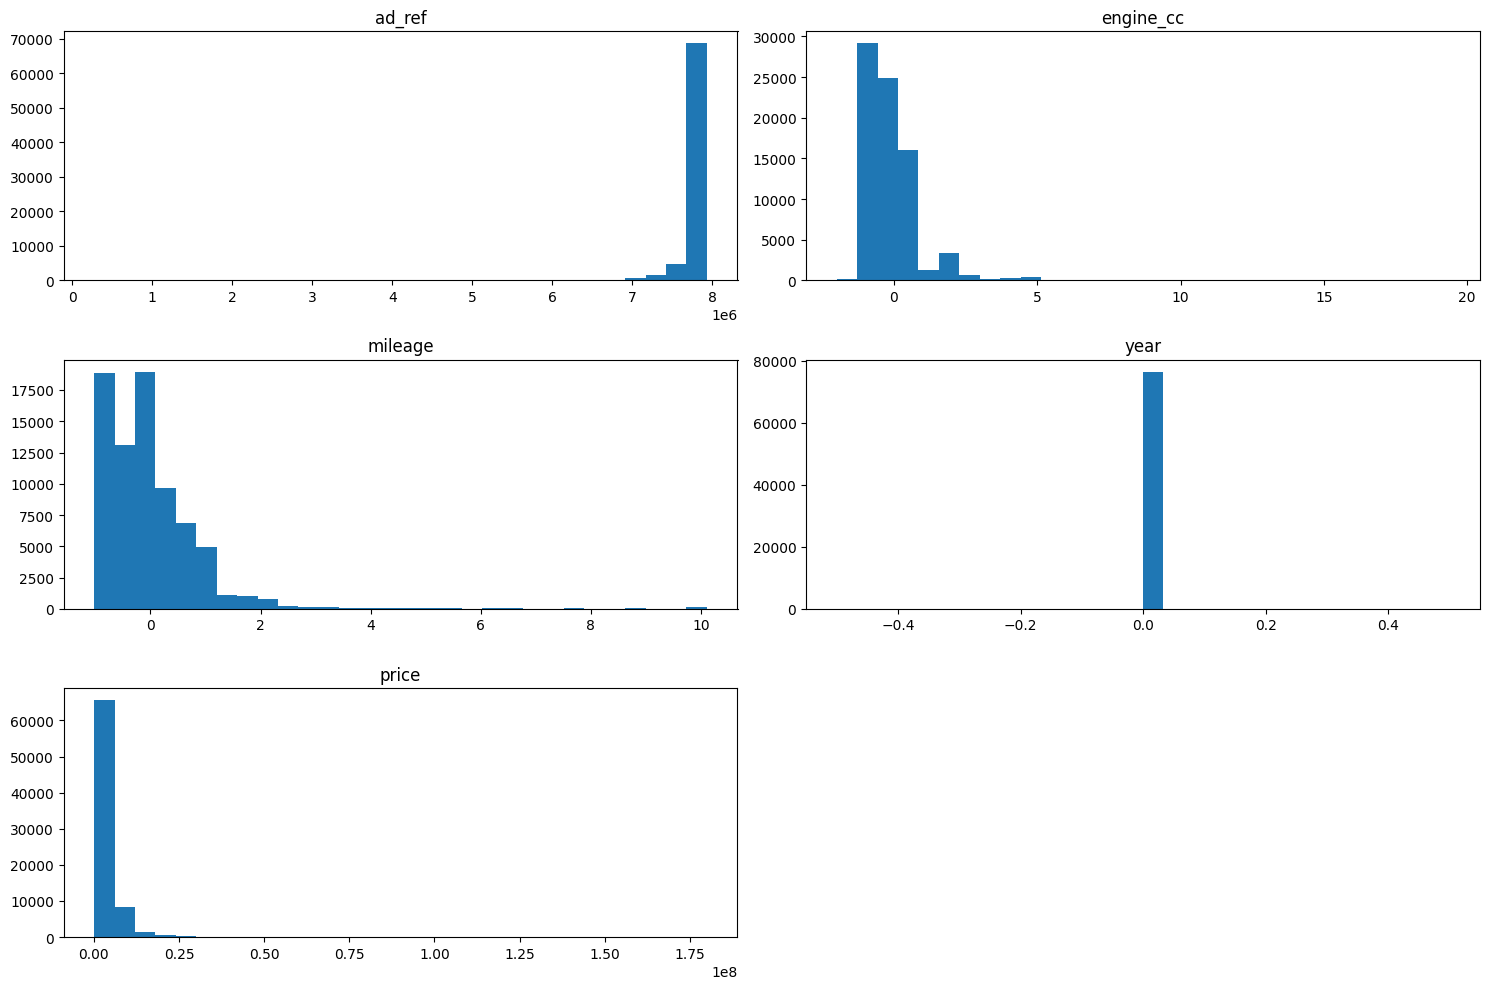

In [ ]:
# 1. Exploratory Data Analysis (EDA)
print(df.describe())

# 2. Visualization

## Histograms
df.hist(bins=30, figsize=(15, 10), grid=False)
plt.tight_layout()
plt.show()

## Scatter Plots
sns.pairplot(df, diag_kind='kde')
plt.show()

## Box Plots
plt.figure(figsize=(15, 10))
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.show()

## Correlation Heatmaps
plt.figure(figsize=(15, 10))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()


### Machine Learning Models

In [ ]:

# Regression Task
print("Training and evaluating models...")

# 1. Ridge Regression
ridge = Ridge()
ridge.fit(X_train, y_train)
y_pred_ridge = ridge.predict(X_test)
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)

# 2. Lasso Regression
lasso = Lasso()
lasso.fit(X_train, y_train)
y_pred_lasso = lasso.predict(X_test)
mse_lasso = mean_squared_error(y_test, y_pred_lasso)
r2_lasso = r2_score(y_test, y_pred_lasso)

# 3. Gradient Boosting Regressor
gbr = GradientBoostingRegressor(random_state=42)
gbr.fit(X_train, y_train)
y_pred_gbr = gbr.predict(X_test)
mse_gbr = mean_squared_error(y_test, y_pred_gbr)
r2_gbr = r2_score(y_test, y_pred_gbr)

# Model Evaluation
results = pd.DataFrame({
    'Model': ['Ridge Regression', 'Lasso Regression', 'Gradient Boosting Regressor'],
    'MSE': [mse_ridge, mse_lasso, mse_gbr],
    'R2 Score': [r2_ridge, r2_lasso, r2_gbr]
})

print("Model evaluation results:")
print(results)
